In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns

In [6]:
corr_feather_paths = {
    path.stem.split(".")[0]: path
    for path in Path("../data/hamburg/correlations").glob("*.joined.corr.combined.feather")
}
corr_feather_paths

{'Col_ColLer': PosixPath('../data/hamburg/correlations/Col_ColLer.joined.corr.combined.feather'),
 'Col_tColaLer': PosixPath('../data/hamburg/correlations/Col_tColaLer.joined.corr.combined.feather'),
 'aColaLer_Col': PosixPath('../data/hamburg/correlations/aColaLer_Col.joined.corr.combined.feather'),
 'ColLer_Col': PosixPath('../data/hamburg/correlations/ColLer_Col.joined.corr.combined.feather'),
 'Col_aColaLer': PosixPath('../data/hamburg/correlations/Col_aColaLer.joined.corr.combined.feather'),
 'tColaLer_Col': PosixPath('../data/hamburg/correlations/tColaLer_Col.joined.corr.combined.feather')}

In [9]:
df = None

for name, path in corr_feather_paths.items():
    df_tmp = pd.read_feather(path)
    df_tmp.rename(columns=lambda col: f"{col}_{name}", inplace=True)
    if df is None:
        df = df_tmp
    else:
        df = df.join(df_tmp, how="inner")

assert df is not None
df.shape

(31269324, 30)

In [10]:
df.columns

Index(['1_Col_ColLer', '2_Col_ColLer', '3_Col_ColLer', '4_Col_ColLer',
       '5_Col_ColLer', '1_Col_tColaLer', '2_Col_tColaLer', '3_Col_tColaLer',
       '4_Col_tColaLer', '5_Col_tColaLer', '1_aColaLer_Col', '2_aColaLer_Col',
       '3_aColaLer_Col', '4_aColaLer_Col', '5_aColaLer_Col', '1_ColLer_Col',
       '2_ColLer_Col', '3_ColLer_Col', '4_ColLer_Col', '5_ColLer_Col',
       '1_Col_aColaLer', '2_Col_aColaLer', '3_Col_aColaLer', '4_Col_aColaLer',
       '5_Col_aColaLer', '1_tColaLer_Col', '2_tColaLer_Col', '3_tColaLer_Col',
       '4_tColaLer_Col', '5_tColaLer_Col'],
      dtype='object')

In [11]:
df.head()

,1_Col_ColLer,2_Col_ColLer,3_Col_ColLer,4_Col_ColLer,5_Col_ColLer,1_Col_tColaLer,2_Col_tColaLer,3_Col_tColaLer,4_Col_tColaLer,5_Col_tColaLer,...,1_Col_aColaLer,2_Col_aColaLer,3_Col_aColaLer,4_Col_aColaLer,5_Col_aColaLer,1_tColaLer_Col,2_tColaLer_Col,3_tColaLer_Col,4_tColaLer_Col,5_tColaLer_Col
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAAAAAAAAAAAAAAAAAAAG,0.007635,0.037383,-0.080028,-0.470359,-0.095074,0.033120,0.135064,0.022142,-0.327344,-0.073923,...,0.074363,0.017635,-0.049185,-0.320848,-0.109882,0.047928,0.065671,-0.228059,-0.513192,0.029645
AAAAAAAAAAAAAAAAAAAAAAT,0.095866,-0.032075,-0.163477,-0.035904,-0.214911,-0.152069,-0.003365,0.069211,0.045978,0.114569,...,0.031427,0.109156,0.166566,0.049958,-0.180966,-0.049987,0.054018,-0.099995,-0.084989,-0.158841
AAAAAAAAAAAAAAAAAAAAACG,0.062797,-0.067435,0.083978,0.001512,-0.026108,0.062035,0.051977,-0.083720,0.134239,-0.042184,...,0.052469,-0.144262,0.022753,0.167928,0.188214,0.139604,0.013748,-0.076922,-0.008543,0.077288
AAAAAAAAAAAAAAAAAAAAAGG,-0.069464,-0.067622,-0.049354,-0.472716,-0.068523,0.148429,0.114371,0.048918,-0.414792,-0.060706,...,0.047029,0.040109,-0.080335,-0.255015,-0.126888,0.109252,0.197455,-0.097247,-0.460709,-0.078425
AAAAAAAAAAAAAAAAAAAAATT,0.046433,-0.024341,-0.170101,0.122011,-0.097482,-0.066154,0.037764,0.027342,0.033901,0.088831,...,-0.035078,0.064911,0.117439,0.066153,-0.136237,-0.201856,0.031117,-0.058155,-0.082085,-0.042770


In [12]:
df.to_feather("../data/hamburg/correlations/inner-joined-corr.feather", compression="zstd", compression_level=8)

In [2]:
df = pd.read_feather("../data/hamburg/correlations/inner-joined-corr.feather")
df.shape

(31269324, 30)

Text(0.5, 1.0, 'Correlation Distribution')

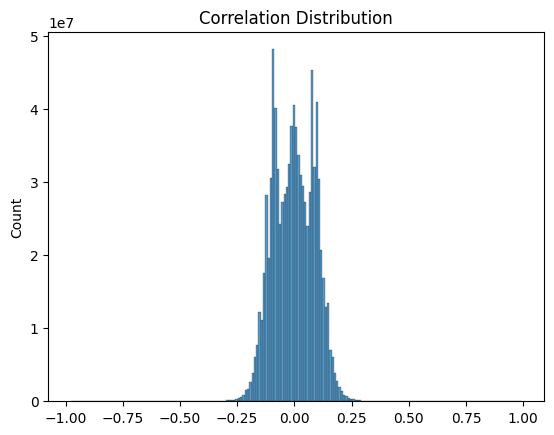

In [4]:
sns.histplot(df.values.flatten(), binwidth=0.01).set_title("Correlation Distribution")

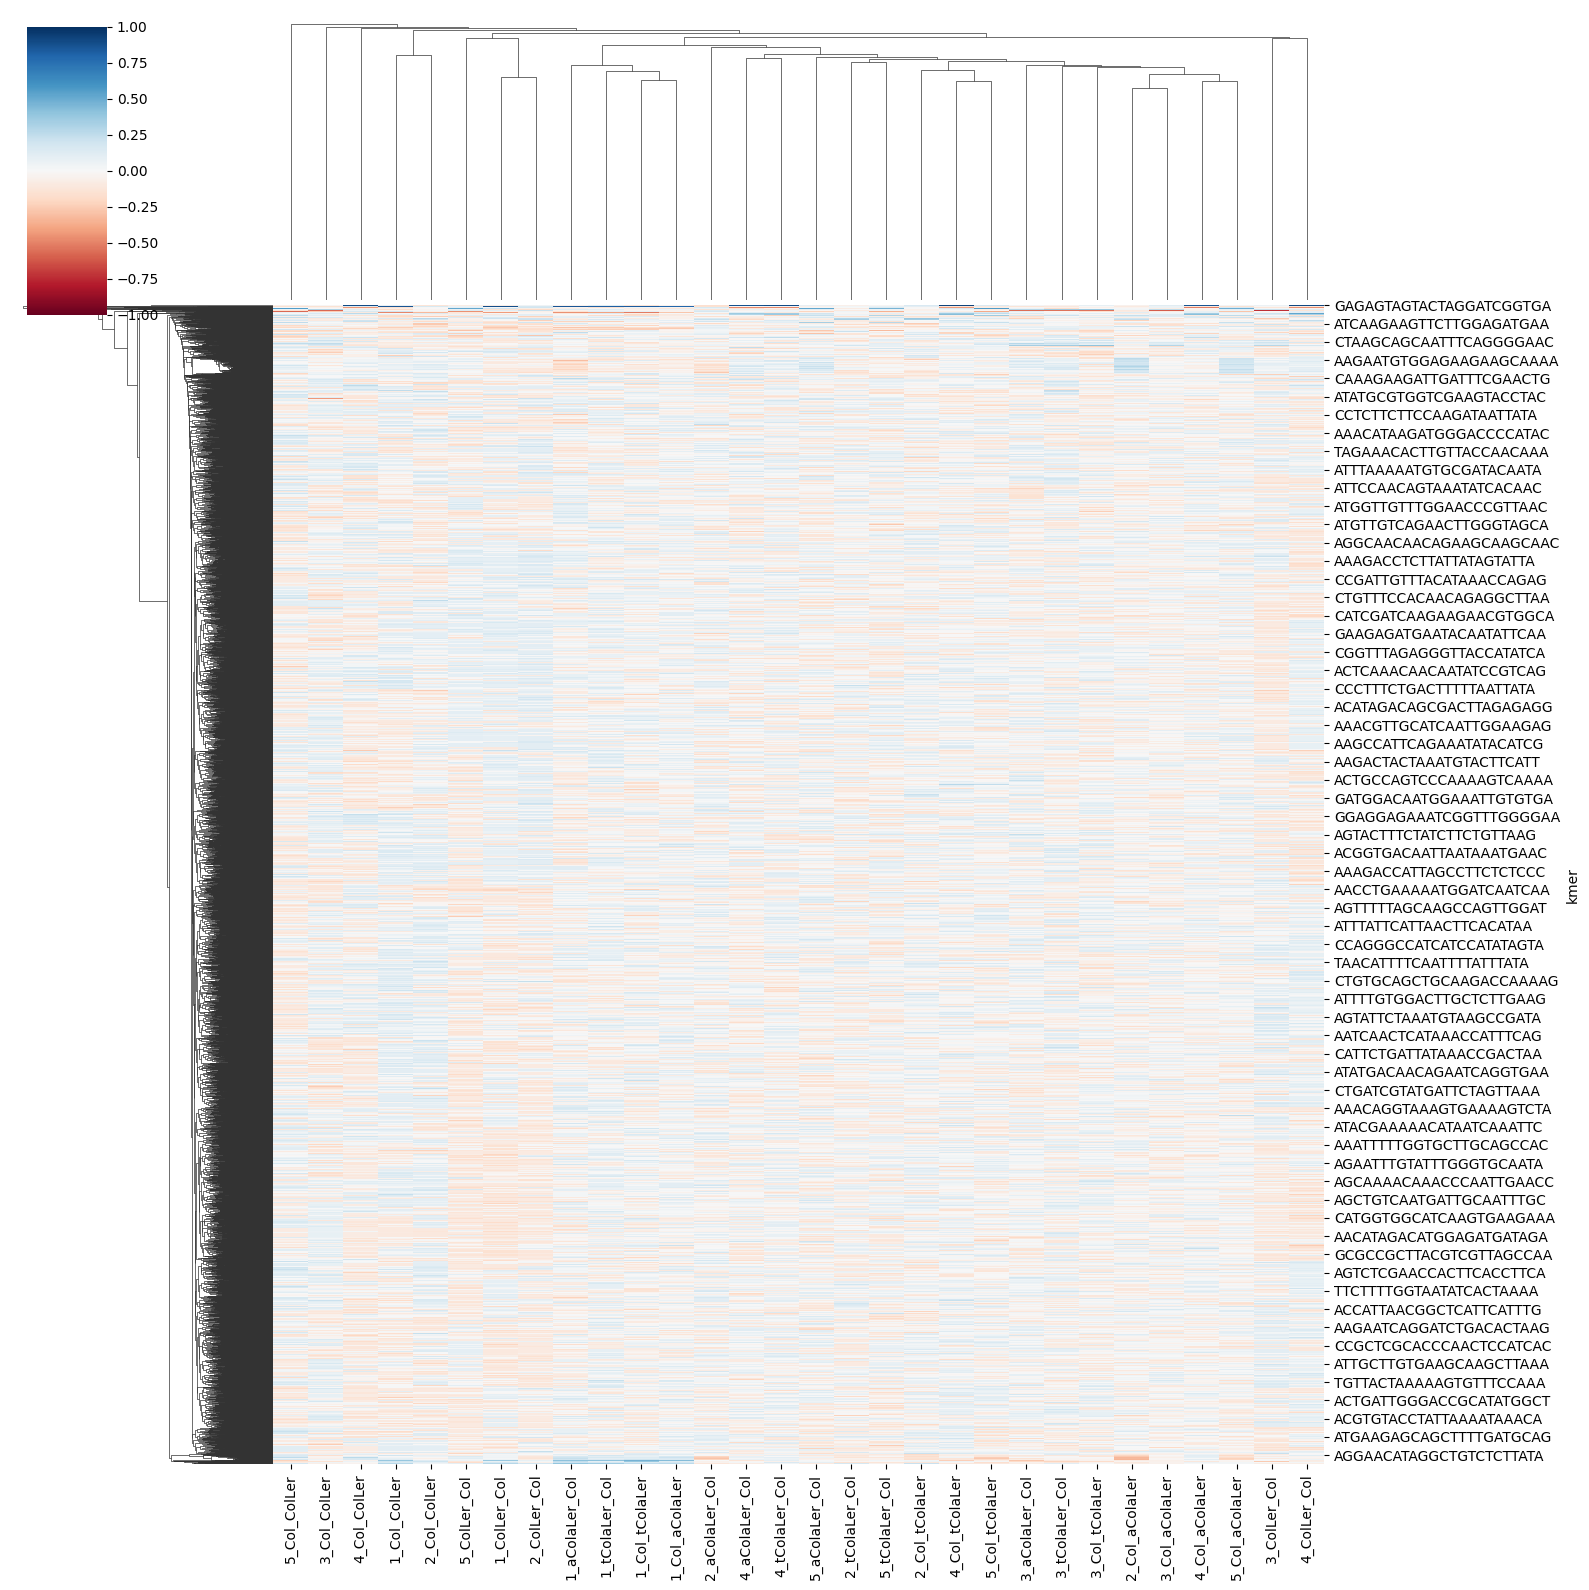

In [5]:
sns.clustermap(
    df.sample(8192),
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

Text(0.5, 1.0, 'Correlation Distribution')

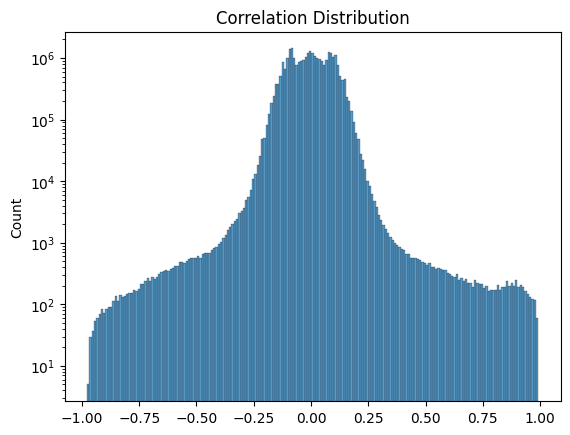

In [6]:
plt = sns.histplot(df.sample(1_000_000).values.flatten(), binwidth=0.01)
plt.set_yscale("log")
plt.set_title("Correlation Distribution")

In [4]:
df_filtered = df[df.abs().max(axis=1) > 0.5]
df_filtered.shape

(174728, 30)

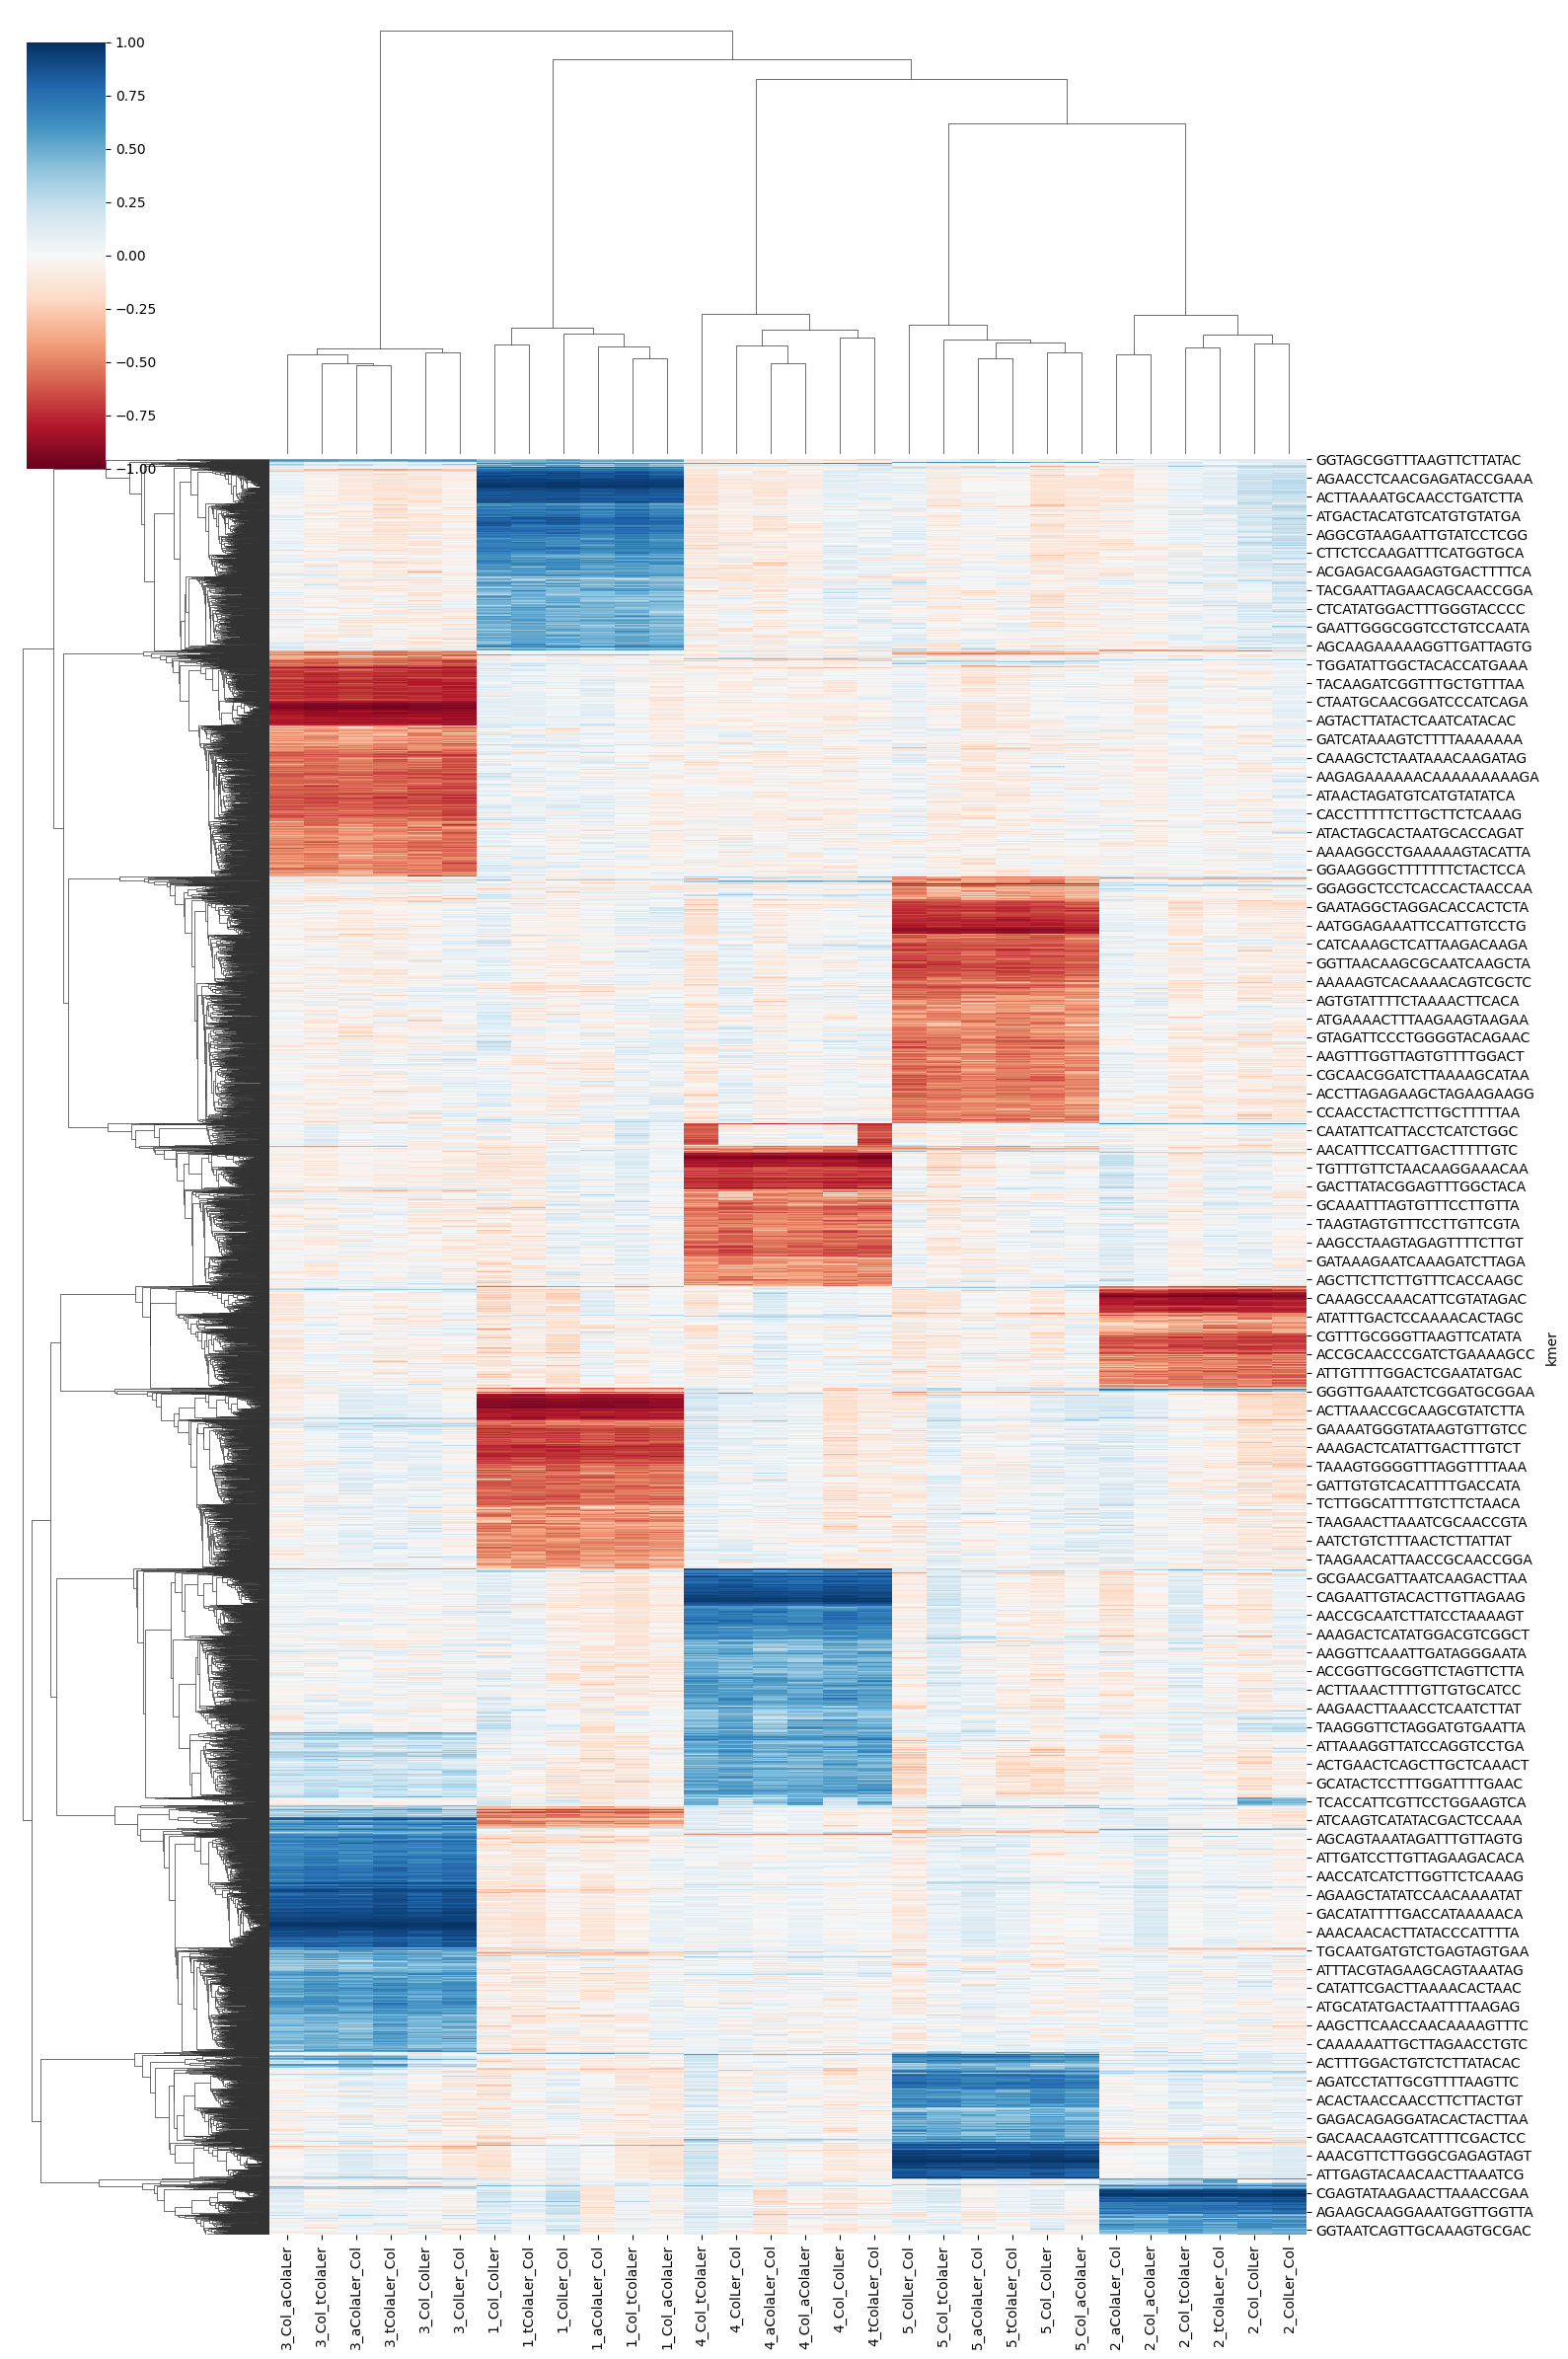

In [11]:
sns.clustermap(
    df_filtered.sample(8192),
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)

In [5]:
df2 = df_filtered[(df_filtered.max(axis=1) > 0.5) & (df_filtered.min(axis=1) < -0.5)]
df2.shape

(1415, 30)

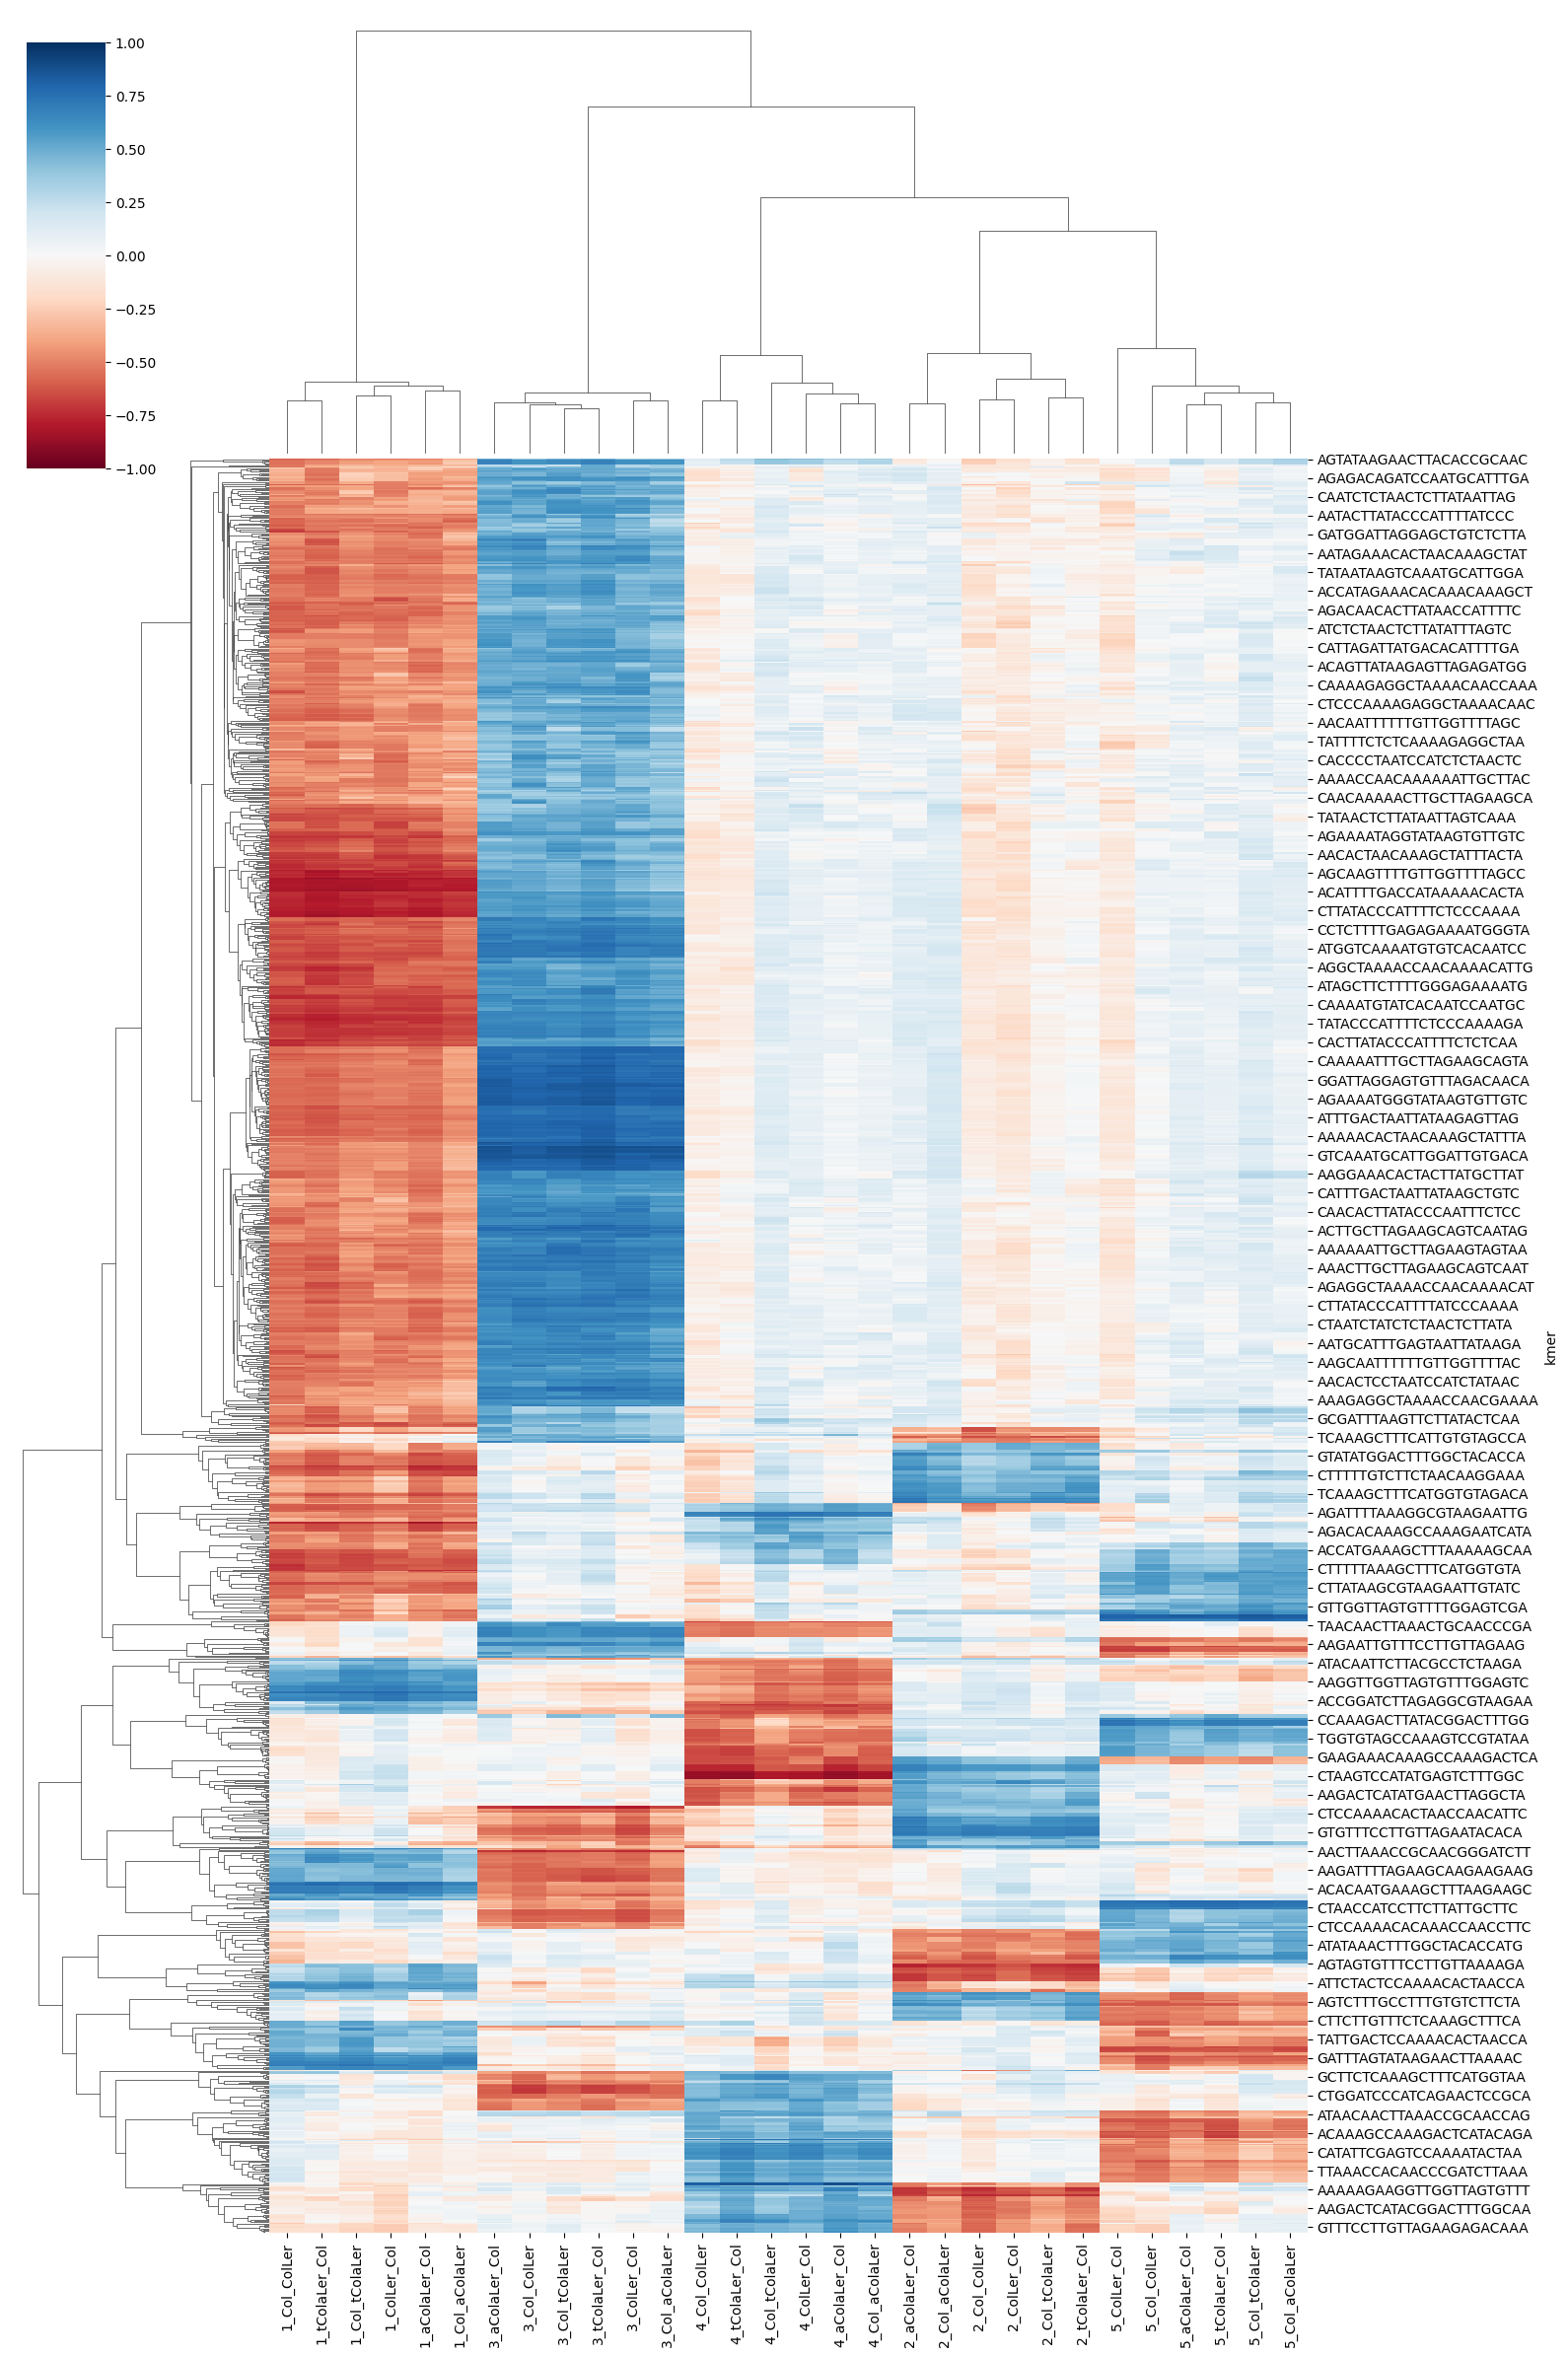

In [6]:
sns.clustermap(
    df2,
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)

In [3]:
df3 = df[df.abs().max(axis=1) > 0.25]
df3.shape

(1685952, 30)

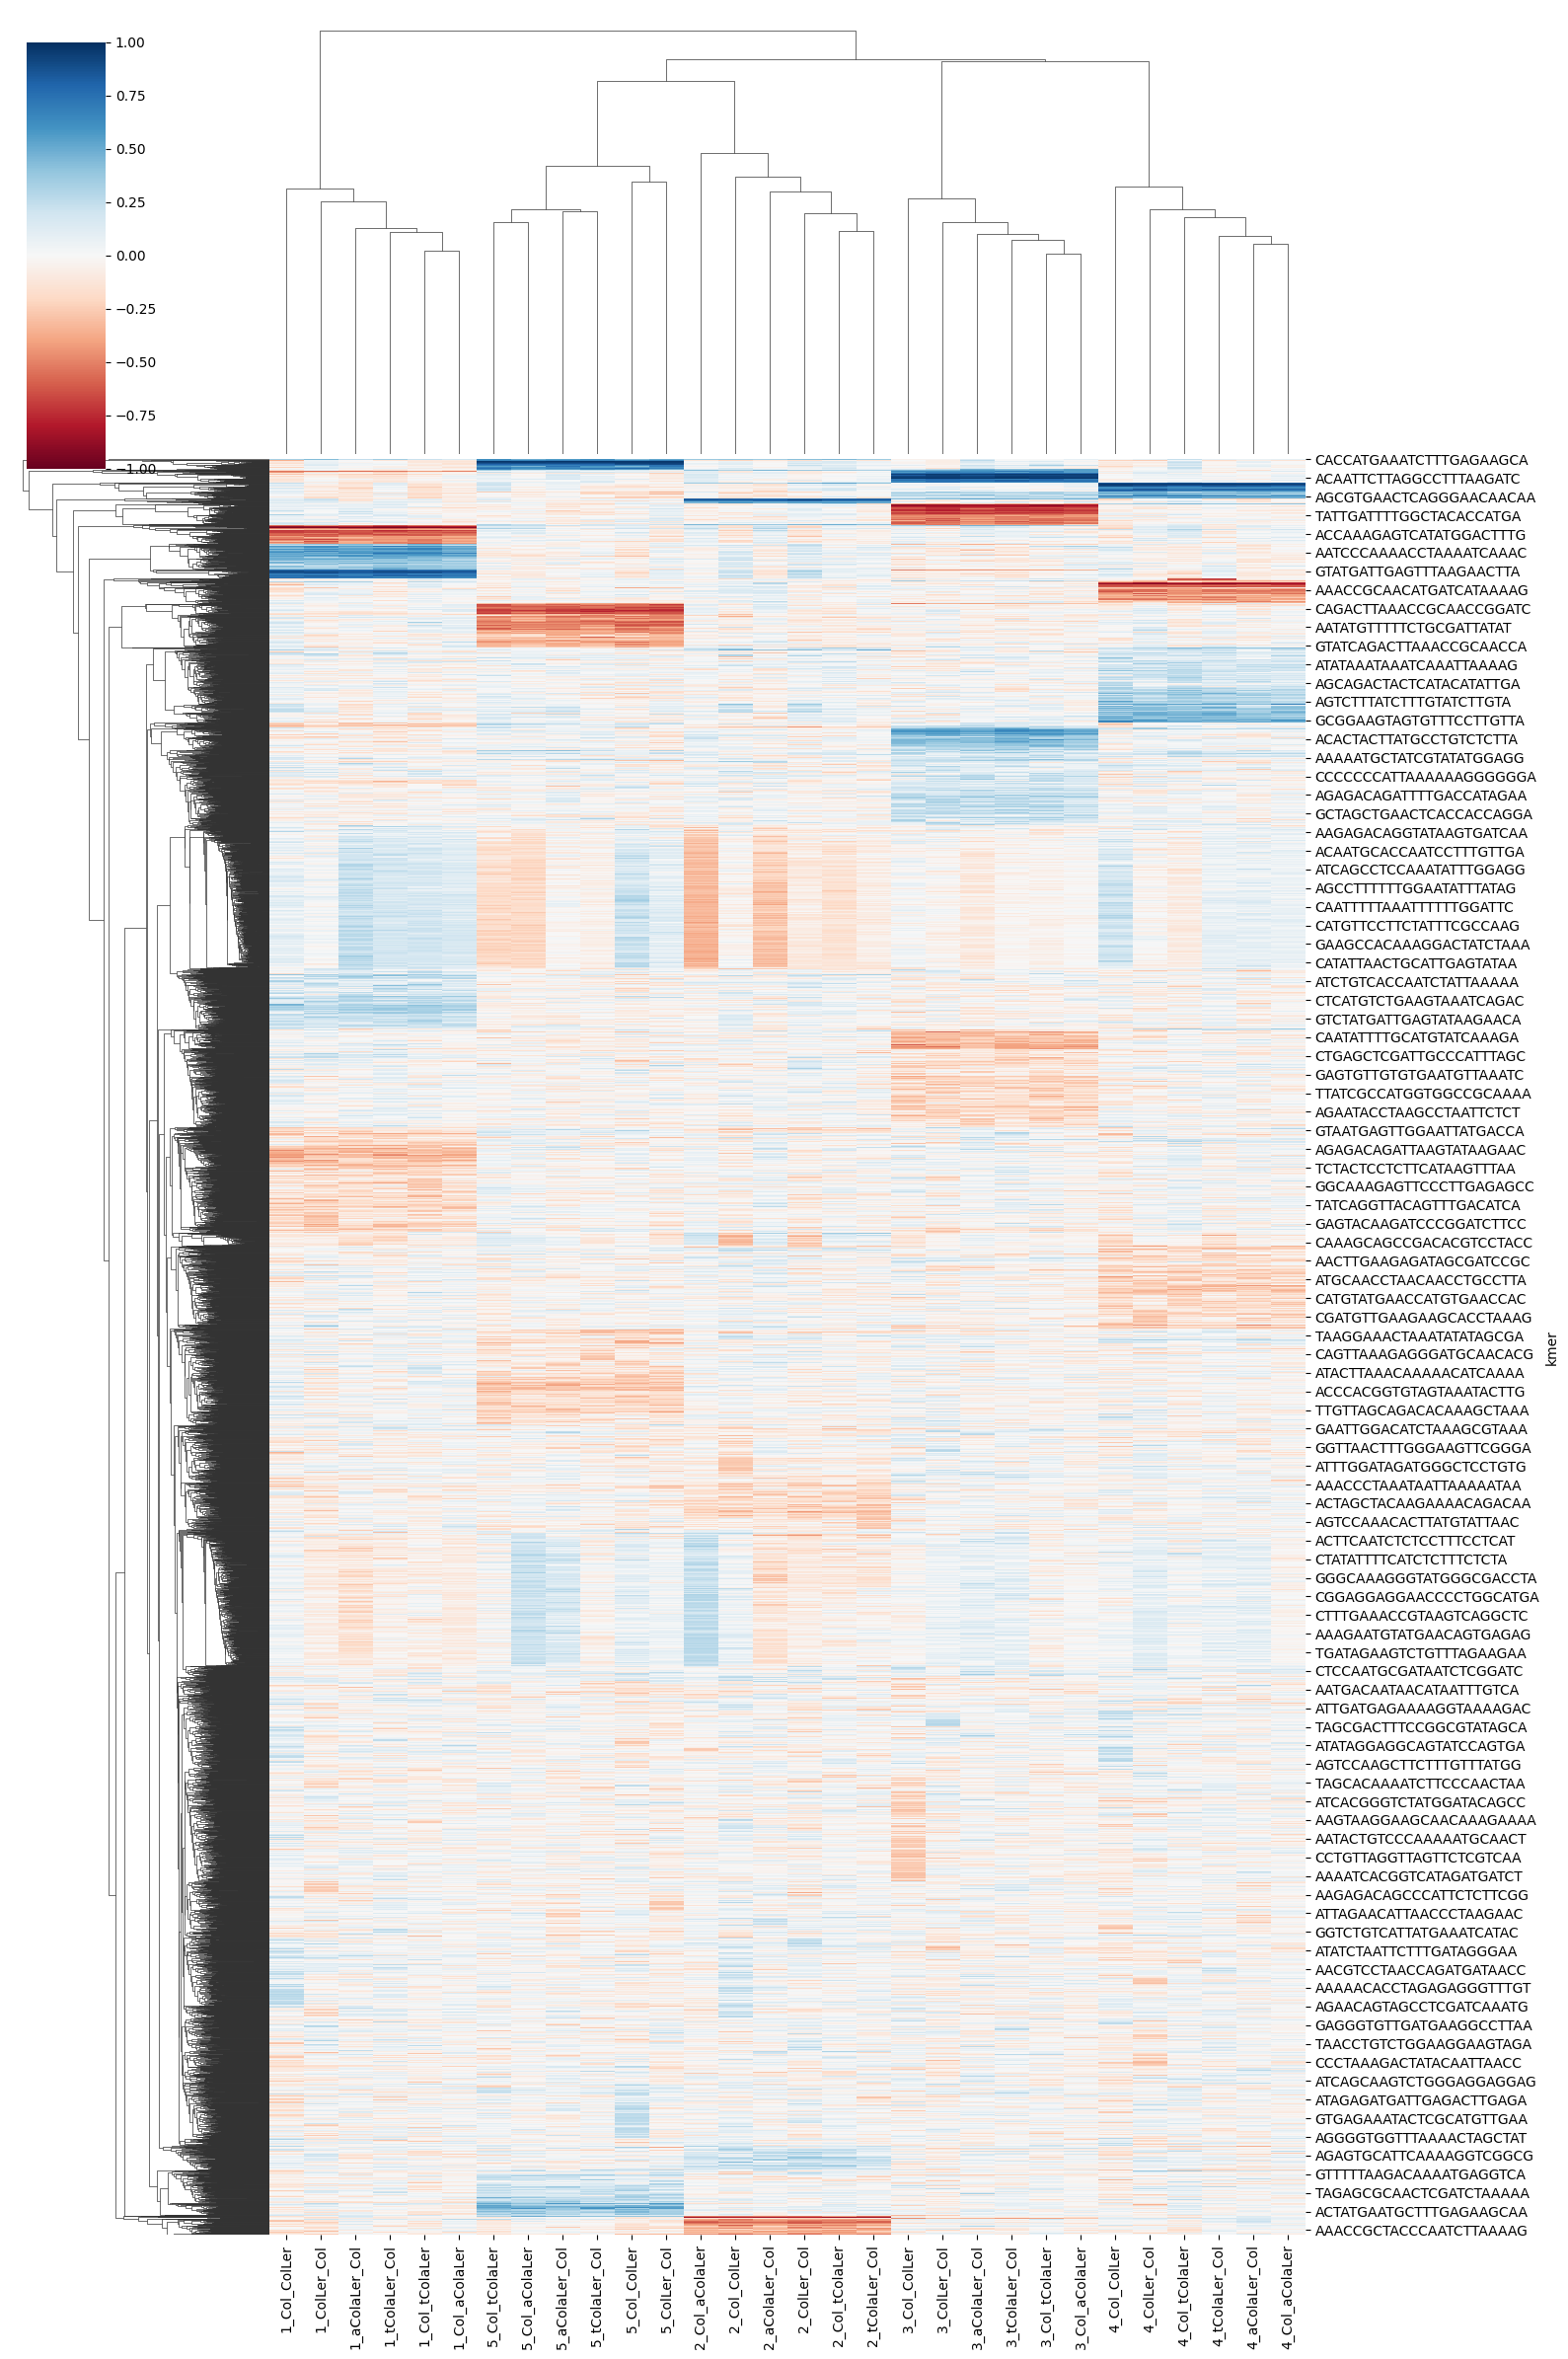

In [8]:
sns.clustermap(
    df3.sample(8192),
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)

In [4]:
df4 = df3[(df3.max(axis=1) > 0.25) & (df3.min(axis=1) < -0.25)]
df4.shape

(179529, 30)

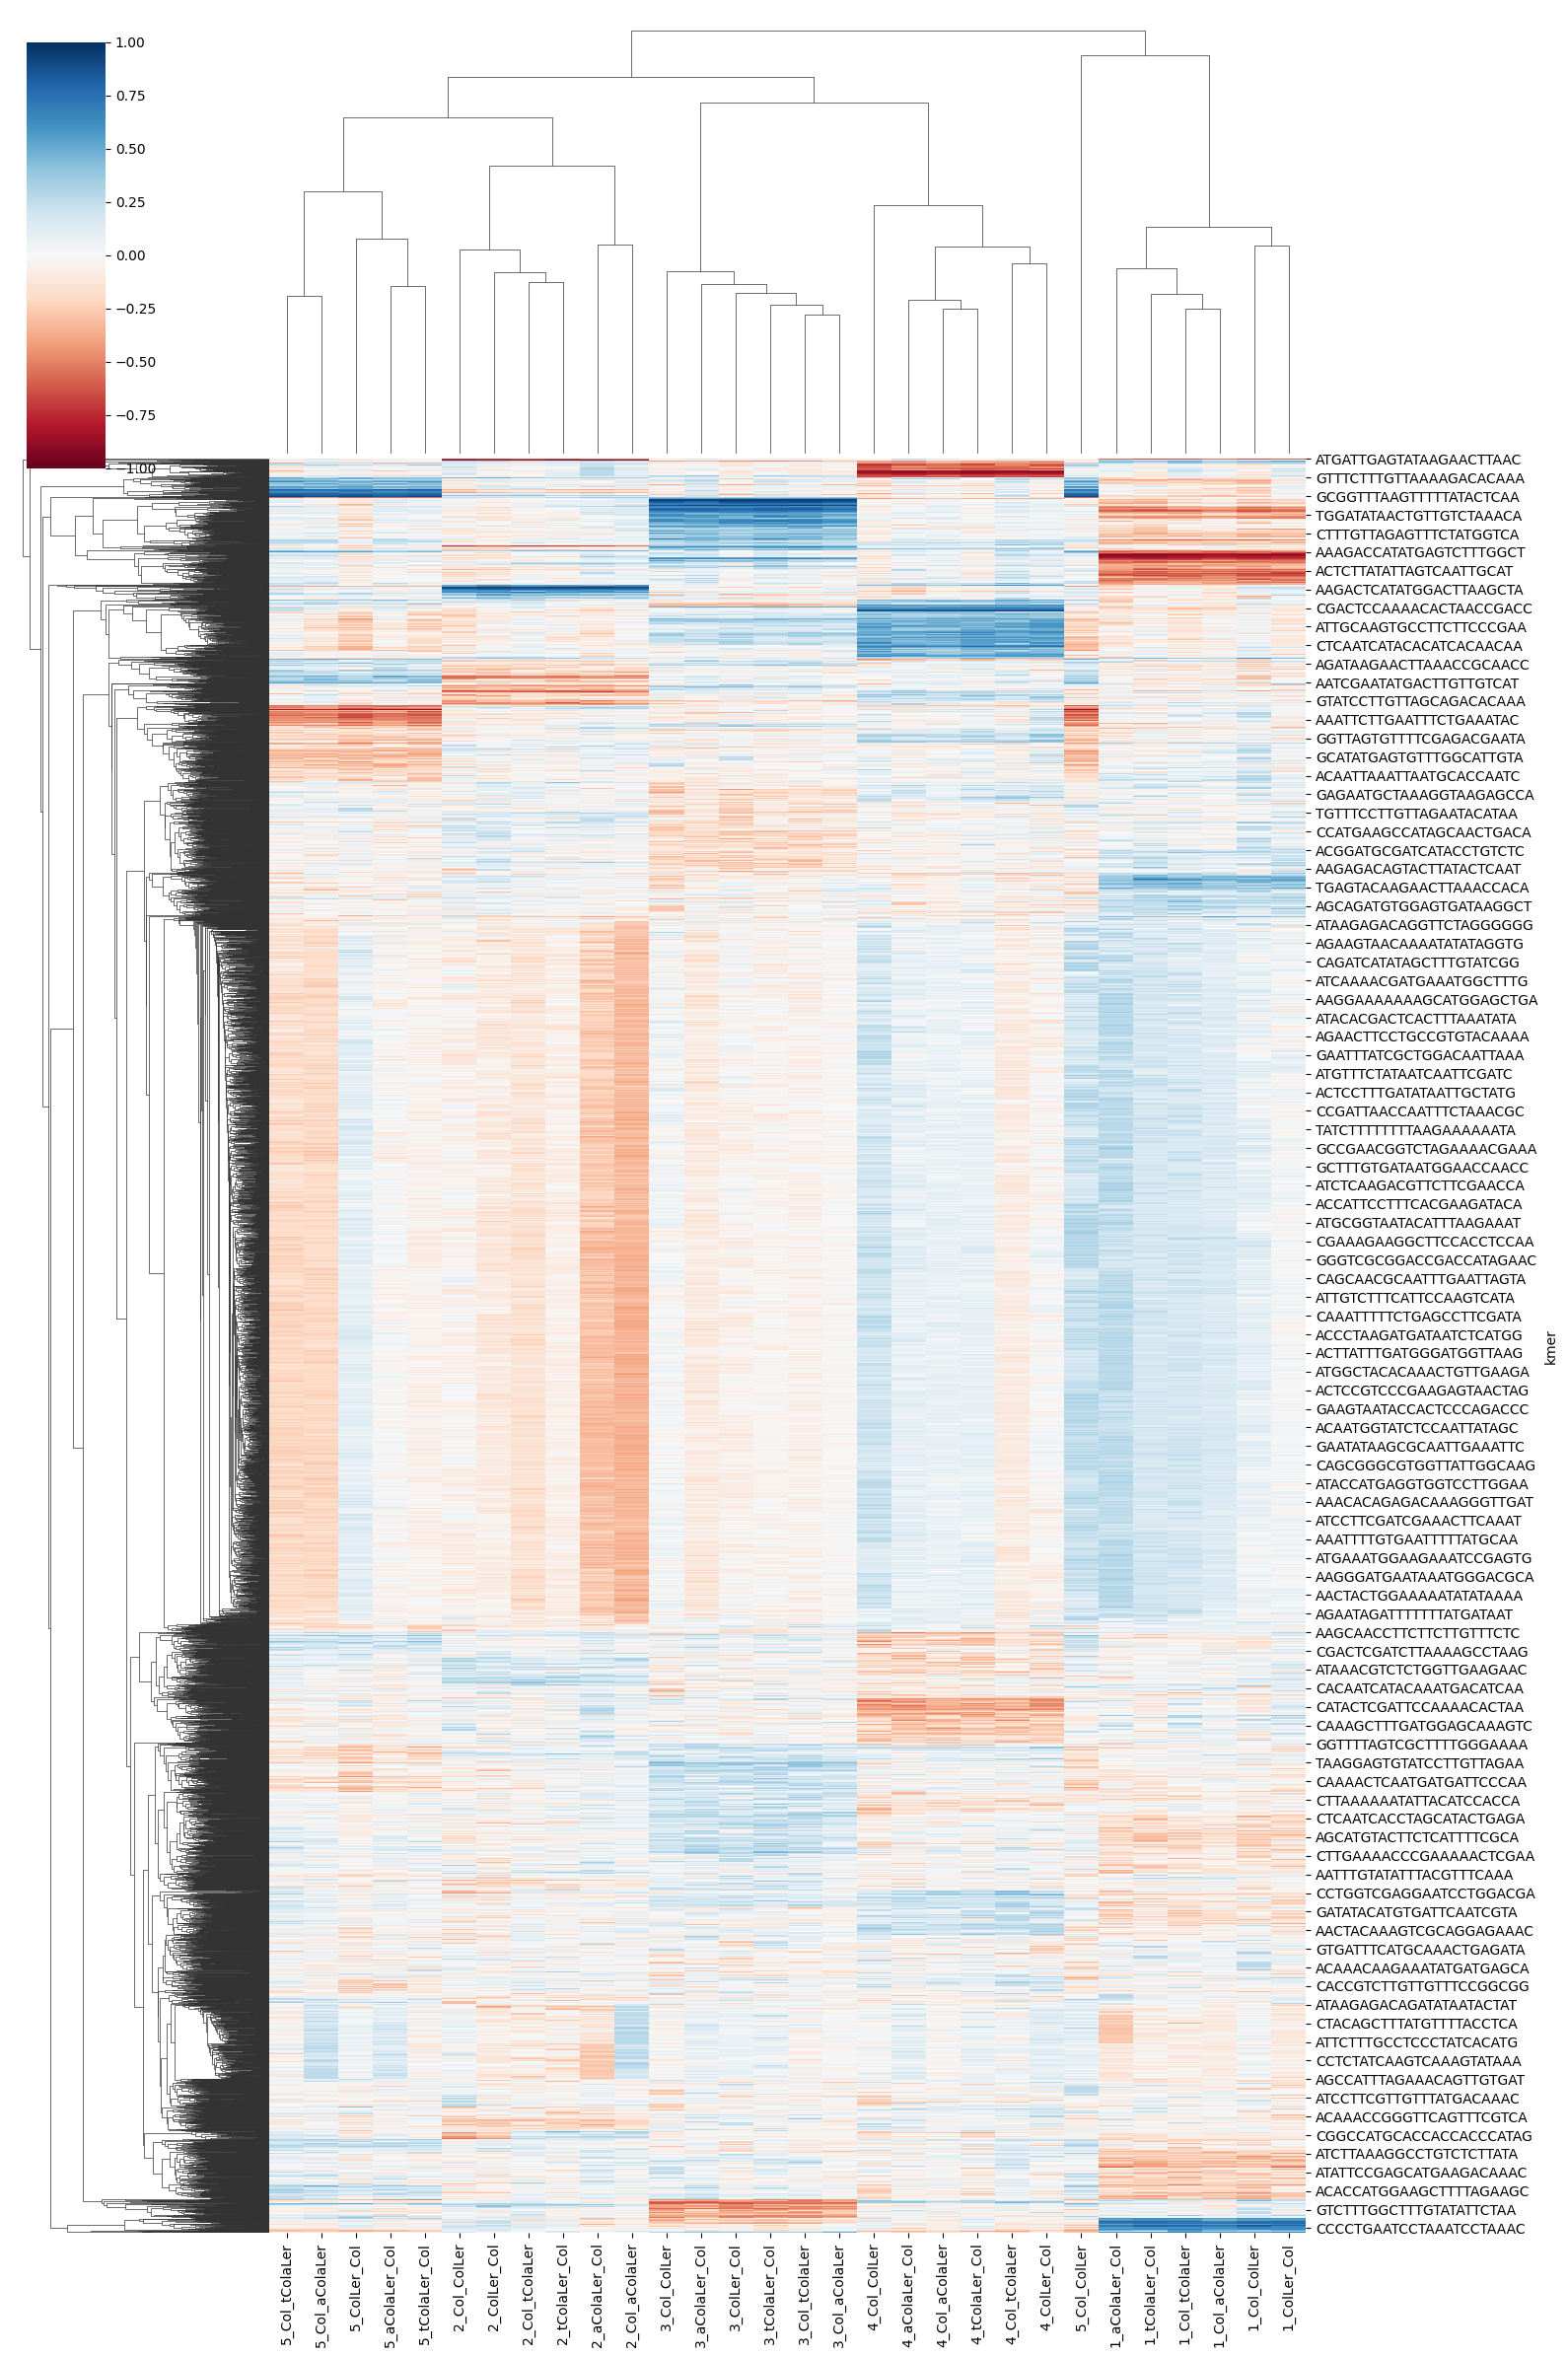

In [5]:
sns.clustermap(
    df4.sample(8192),
    cmap="RdBu",
    figsize=(16, 24),
    vmin=-1,
    vmax=1,
)